# Tech Challenge Fase 04 — Obesidade
## Notebook 01 — Engenharia de Dados & Análise Exploratória
**Pessoa 1 | POSTECH Data Analytics**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})


## 1. Carregamento dos Dados

In [2]:
df = pd.read_csv('Obesity.csv')
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()


Linhas: 2111 | Colunas: 17


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Inspeção Inicial

In [3]:
print("Tipos de dados:")
print(df.dtypes)
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nDuplicatas: {df.duplicated().sum()}")


Tipos de dados:
Gender                str
Age               float64
Height            float64
Weight            float64
family_history        str
FAVC                  str
FCVC              float64
NCP               float64
CAEC                  str
SMOKE                 str
CH2O              float64
SCC                   str
FAF               float64
TUE               float64
CALC                  str
MTRANS                str
Obesity               str
dtype: object

Valores nulos:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

Duplicatas: 24


In [4]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## 3. Limpeza e Tratamento

As colunas FCVC, NCP, CH2O, FAF e TUE são escalas inteiras, mas aparecem com decimais no dataset (ruído de coleta). Vamos arredondá-las conforme o dicionário de dados.


In [5]:
cols_ord = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in cols_ord:
    df[col] = df[col].round().astype(int)

# IMC como feature auxiliar
df['IMC'] = (df['Weight'] / (df['Height'] ** 2)).round(2)

# Ordem lógica do target
obesity_order = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
df['Obesity'] = pd.Categorical(df['Obesity'], categories=obesity_order, ordered=True)

print("Tratamento concluído.")
print(f"Shape final: {df.shape}")


Tratamento concluído.
Shape final: (2111, 18)


In [6]:
# Exportar dataset limpo para modelagem
df.to_csv('obesity_clean.csv', index=False)
print("Dataset salvo: obesity_clean.csv")


Dataset salvo: obesity_clean.csv


## 4. Análise Exploratória

### 4.1 Distribuição dos Níveis de Obesidade

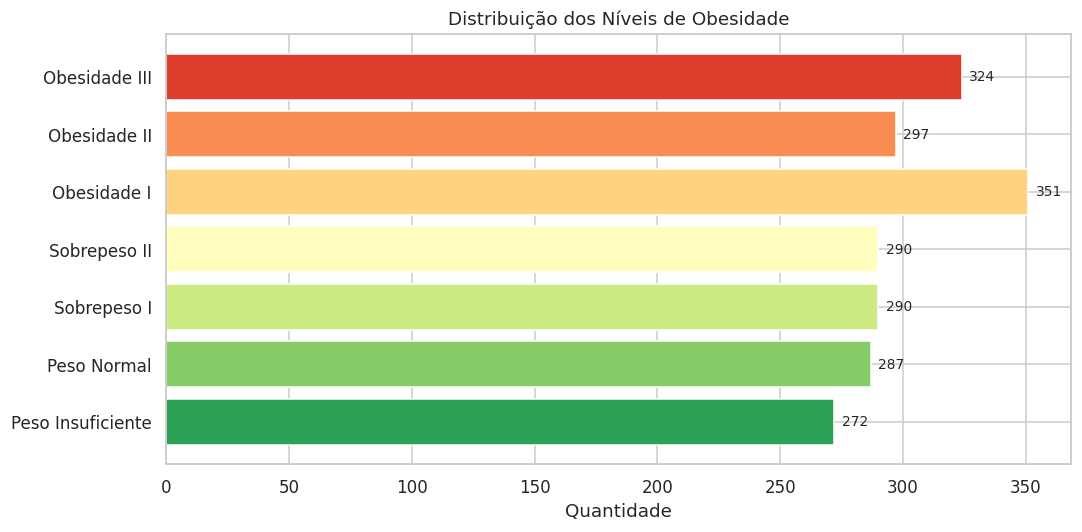

Insight: dataset bem balanceado. Maioria da amostra está em algum grau de sobrepeso ou obesidade.


In [7]:
rotulos_pt = {
    'Insufficient_Weight': 'Peso Insuficiente',
    'Normal_Weight': 'Peso Normal',
    'Overweight_Level_I': 'Sobrepeso I',
    'Overweight_Level_II': 'Sobrepeso II',
    'Obesity_Type_I': 'Obesidade I',
    'Obesity_Type_II': 'Obesidade II',
    'Obesity_Type_III': 'Obesidade III'
}

contagem = df['Obesity'].value_counts().reindex(obesity_order)
labels_pt = [rotulos_pt[c] for c in contagem.index]
cores = sns.color_palette("RdYlGn_r", len(obesity_order))

plt.figure(figsize=(10, 5))
bars = plt.barh(labels_pt, contagem.values, color=cores)
for bar, v in zip(bars, contagem.values):
    plt.text(v + 3, bar.get_y() + bar.get_height() / 2, str(v), va='center', fontsize=9)
plt.xlabel("Quantidade")
plt.title("Distribuição dos Níveis de Obesidade")
plt.tight_layout()
plt.show()

# Insight
print("Insight: dataset bem balanceado. Maioria da amostra está em algum grau de sobrepeso ou obesidade.")


### 4.2 Peso e IMC por Nível de Obesidade

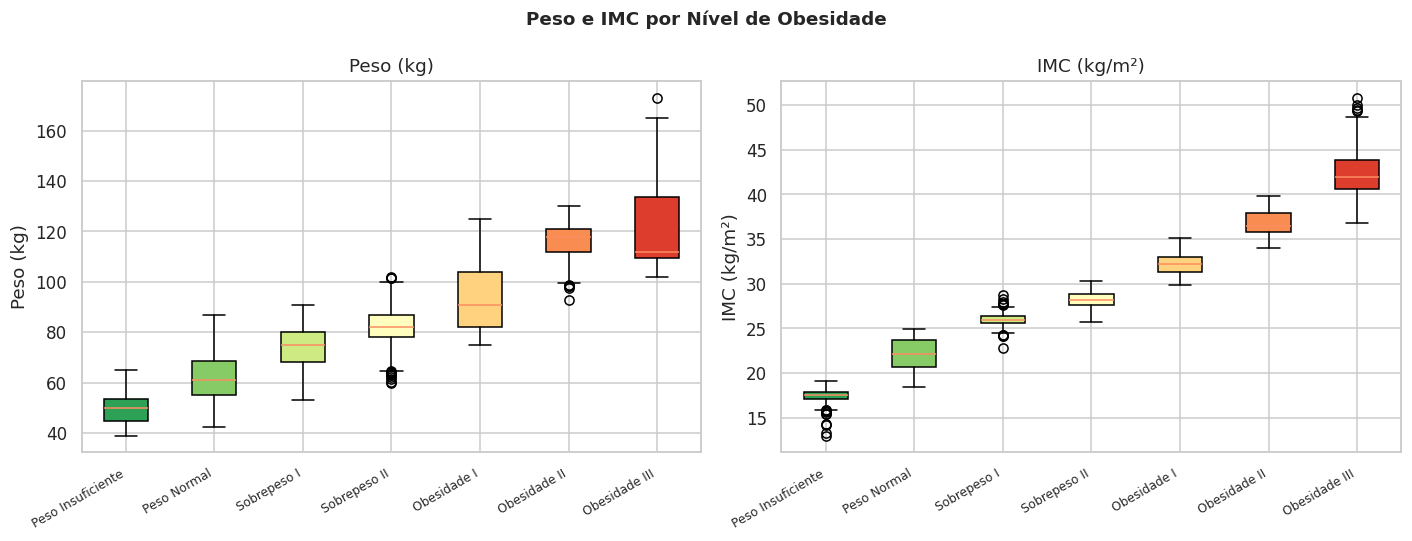

Insight: Peso e IMC crescem de forma progressiva entre as classes — são as variáveis mais discriminativas.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, titulo in zip(axes, ['Weight', 'IMC'], ['Peso (kg)', 'IMC (kg/m²)']):
    data = [df[df['Obesity'] == cat][col].dropna() for cat in obesity_order]
    bp = ax.boxplot(data, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
    ax.set_xticklabels([rotulos_pt[o] for o in obesity_order], rotation=30, ha='right', fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel(titulo)

plt.suptitle("Peso e IMC por Nível de Obesidade", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Peso e IMC crescem de forma progressiva entre as classes — são as variáveis mais discriminativas.")


### 4.3 Idade por Nível de Obesidade

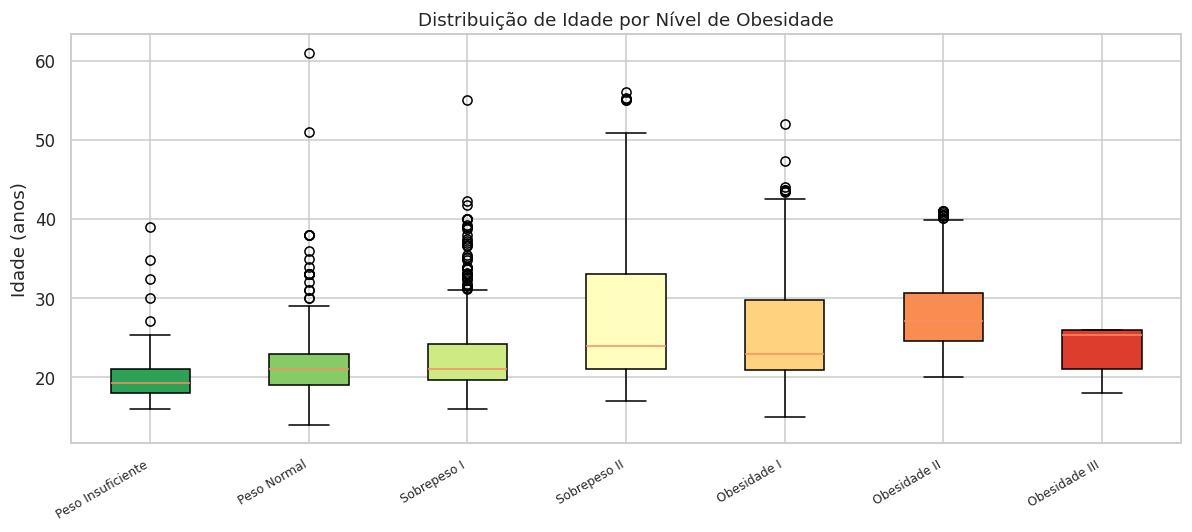

Insight: Obesidade Tipo III concentra indivíduos mais jovens (~20–25 anos).


In [9]:
data_age = [df[df['Obesity'] == cat]['Age'].dropna() for cat in obesity_order]

plt.figure(figsize=(11, 5))
bp = plt.boxplot(data_age, patch_artist=True)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
plt.xticks(range(1, len(obesity_order) + 1),
           [rotulos_pt[o] for o in obesity_order], rotation=30, ha='right', fontsize=8)
plt.ylabel("Idade (anos)")
plt.title("Distribuição de Idade por Nível de Obesidade")
plt.tight_layout()
plt.show()

print("Insight: Obesidade Tipo III concentra indivíduos mais jovens (~20–25 anos).")


### 4.4 Hábitos Alimentares

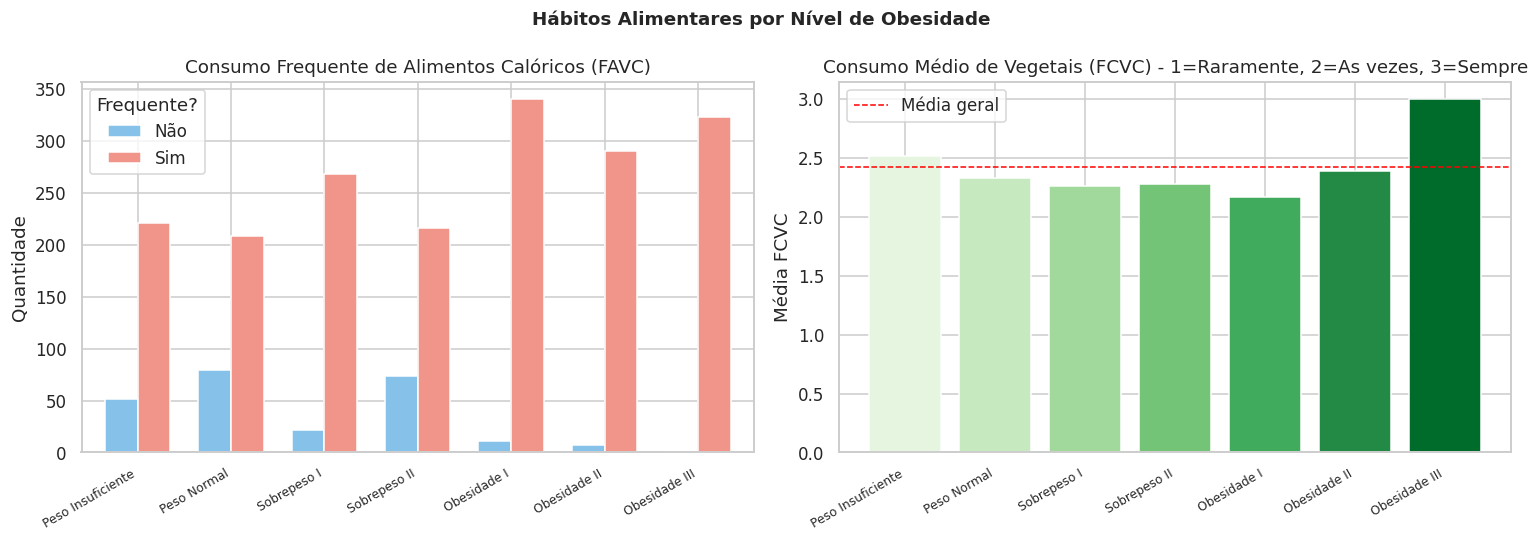

Insight: Consumo de vegetais é menor nos maiores graus de obesidade.
Insight: Alimentos calóricos são comuns em quase todas as classes.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Consumo de alimentos calóricos (FAVC)
favc = df.groupby(['Obesity', 'FAVC']).size().unstack(fill_value=0).reindex(obesity_order)
favc.index = [rotulos_pt[o] for o in obesity_order]
favc.columns = ['Não', 'Sim']
favc.plot(kind='bar', ax=axes[0], color=['#85C1E9', '#F1948A'], edgecolor='white', width=0.7)
axes[0].set_title("Consumo Frequente de Alimentos Calóricos (FAVC)")
axes[0].set_xlabel("")
axes[0].set_xticklabels(favc.index, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Frequente?")

# Consumo de vegetais (média)
fcvc = df.groupby('Obesity')['FCVC'].mean().reindex(obesity_order)
axes[1].bar([rotulos_pt[o] for o in obesity_order], fcvc.values,
            color=sns.color_palette("Greens", len(obesity_order)))
axes[1].axhline(fcvc.mean(), color='red', linestyle='--', linewidth=1, label='Média geral')
axes[1].set_title("Consumo Médio de Vegetais (FCVC) - 1=Raramente, 2=As vezes, 3=Sempre")
axes[1].set_xticklabels([rotulos_pt[o] for o in obesity_order], rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel("Média FCVC")
axes[1].legend()

plt.suptitle("Hábitos Alimentares por Nível de Obesidade", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Consumo de vegetais é menor nos maiores graus de obesidade.")
print("Insight: Alimentos calóricos são comuns em quase todas as classes.")


### 4.5 Frequência de Atividade Física

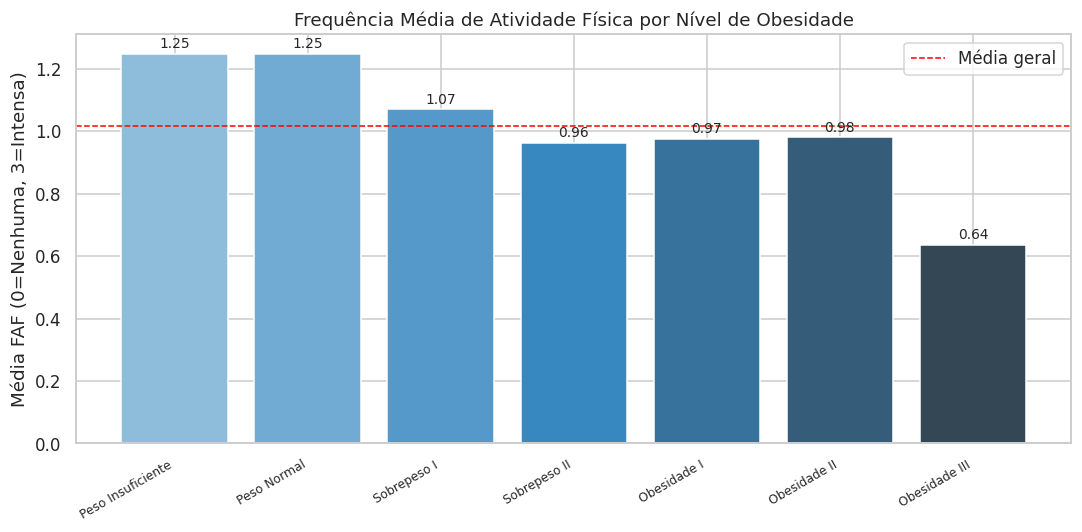

Insight: Quanto maior o grau de obesidade, menor a frequência de atividade física.


In [11]:
faf = df.groupby('Obesity')['FAF'].mean().reindex(obesity_order)

plt.figure(figsize=(10, 5))
bars = plt.bar([rotulos_pt[o] for o in obesity_order], faf.values,
               color=sns.color_palette("Blues_d", len(obesity_order)))
plt.axhline(faf.mean(), color='red', linestyle='--', linewidth=1, label='Média geral')
for i, v in enumerate(faf.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.ylabel("Média FAF (0=Nenhuma, 3=Intensa)")
plt.title("Frequência Média de Atividade Física por Nível de Obesidade")
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: Quanto maior o grau de obesidade, menor a frequência de atividade física.")


## 5. Principais Insights

| # | Insight |
|---|---------|
| 1 | IMC e Peso são as variáveis mais correlacionadas com o nível de obesidade |
| 2 | Histórico familiar é fator de risco relevante |
| 3 | Menor atividade física está associada a maiores graus de obesidade |
| 4 | Obesity Tipo III concentra indivíduos mais jovens |
| 5 | Consumo de vegetais é menor nos maiores graus de obesidade |

## 6. Dataset para Modelagem

Arquivo exportado: `obesity_clean.csv`
- Variáveis ordinais arredondadas (FCVC, NCP, CH2O, FAF, TUE)
- Feature IMC adicionada
- Sem valores nulos
- 2111 registros | 18 colunas
